<a href="https://colab.research.google.com/github/himanshu-js/Titanic_Dataset_Cleaning/blob/main/Titanic_cleaned_dataset/Titanic_Dataset_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [76]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
df_original = df
df_original

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [35]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# Understand the Dataset Structure

In [37]:
df.shape # Number of rows and columns

(891, 12)

In [38]:
df.info() # Data type and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [39]:
df.describe()  # Statistical summary

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Check Missing Values

In [40]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [41]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Handle Missing Values

## Fill Numerical Columns

In [42]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [43]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Fill Categorical Columns

In [44]:
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['Cabin'] = df['Cabin'].astype(str).str[0]

# Replace and Rename

In [45]:
# Replacing S,C & Q with full names
# Filling the nan values with mostly repeated value
df['Embarked'] = df['Embarked'].replace({'S':'Southampton','C':'Cherburg','Q':'Queenstown',None:'Southampton'})


In [46]:
# renaming the columns
df = df.rename(columns={'Pclass':'Passenger Class','SibSp':'Siblings/Spouses Aboard','Parch':'Parents/Children Aboard'})

In [47]:
# replacing the passenger class with 1st,2nd & 3rd
df['Passenger Class'] = df['Passenger Class'].replace({1:'1st',2:'2nd',3:'3rd'})

In [48]:
df.head()

,PassengerId,Survived,Passenger Class,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Ticket,Fare,Cabin,Embarked
0,1,0,3rd,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,Southampton
1,2,1,1st,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Cherburg
2,3,1,3rd,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,Southampton
3,4,1,1st,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,Southampton
4,5,0,3rd,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,Southampton


# Family Size Column

In [49]:
df['Family_size'] = df['Siblings/Spouses Aboard'] + df['Parents/Children Aboard'] + 1
df

,PassengerId,Survived,Passenger Class,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Ticket,Fare,Cabin,Embarked,Family_size
0,1,0,3rd,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,Southampton,2
1,2,1,1st,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Cherburg,2
2,3,1,3rd,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,Southampton,1
3,4,1,1st,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,Southampton,2
4,5,0,3rd,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,Southampton,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2nd,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,Southampton,1
887,888,1,1st,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B,Southampton,1
888,889,0,3rd,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,U,Southampton,4
889,890,1,1st,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Cherburg,1


In [50]:
def categorized_family(size):
  if size == 1:
    return 'Alone'
  elif size <= 4:
    return 'Small Family'
  else:
    return 'Large Family'

df['Family_type'] = df['Family_size'].apply(categorized_family)


# Fare per Person

In [51]:
df['Fare_per_Person'] = df['Fare'] / df['Family_size']
df

,PassengerId,Survived,Passenger Class,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Ticket,Fare,Cabin,Embarked,Family_size,Family_type,Fare_per_Person
0,1,0,3rd,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,Southampton,2,Small Family,3.62500
1,2,1,1st,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Cherburg,2,Small Family,35.64165
2,3,1,3rd,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,Southampton,1,Alone,7.92500
3,4,1,1st,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,Southampton,2,Small Family,26.55000
4,5,0,3rd,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,Southampton,1,Alone,8.05000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2nd,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,Southampton,1,Alone,13.00000
887,888,1,1st,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B,Southampton,1,Alone,30.00000
888,889,0,3rd,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,U,Southampton,4,Small Family,5.86250
889,890,1,1st,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Cherburg,1,Alone,30.00000


# Fare Column

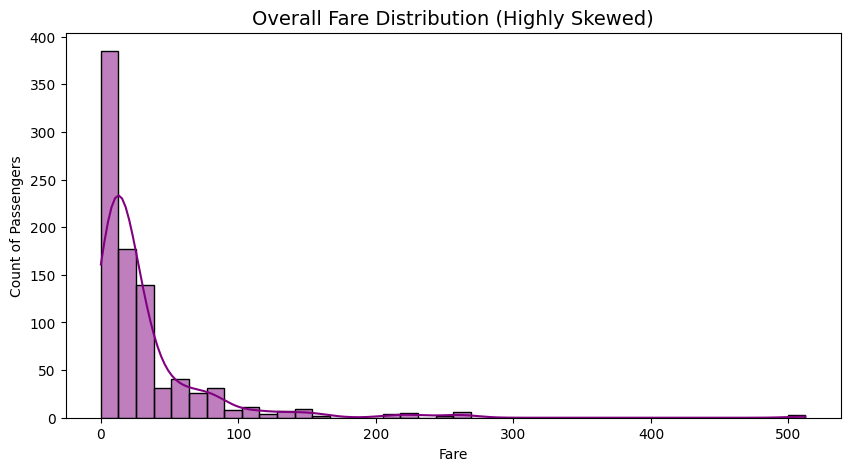

In [52]:
# Create a distribution plot for the raw Fare column
plt.figure(figsize=(10, 5))
sns.histplot(df['Fare'], kde=True, bins=40, color='purple')

plt.title('Overall Fare Distribution (Highly Skewed)', fontsize=14)
plt.xlabel('Fare')
plt.ylabel('Count of Passengers')
plt.show()

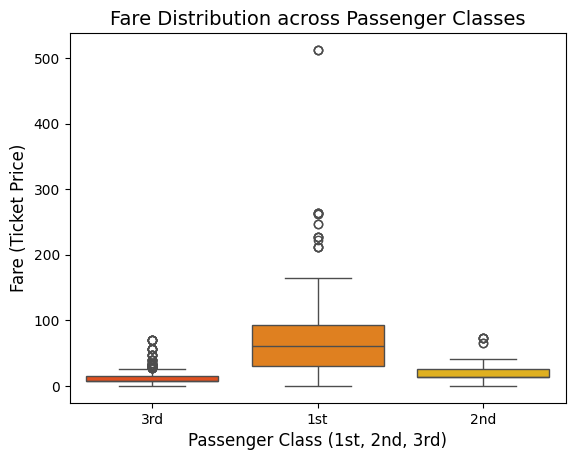

In [53]:
# Fare Distribution in Passenger Classes
sns.boxplot(x = df['Passenger Class'],y= df['Fare'],hue='Passenger Class',data = df,palette='autumn')
plt.title('Fare Distribution across Passenger Classes', fontsize=14)
plt.xlabel('Passenger Class (1st, 2nd, 3rd)', fontsize=12)
plt.ylabel('Fare (Ticket Price)', fontsize=12)
plt.show()


In [54]:
# Find the null
print(df['Fare'].isnull().sum())

0


In [55]:
# Log Transformation using numpy log1p function
# add 0 if fare is 0
# log(1) = 0

df['Log_Fare'] = np.log1p(df['Fare'])
print(df[['Fare', 'Log_Fare']].head())

      Fare  Log_Fare
0   7.2500  2.110213
1  71.2833  4.280593
2   7.9250  2.188856
3  53.1000  3.990834
4   8.0500  2.202765


In [56]:
df = df.drop(columns=['Fare']) # drop the fare column
df

,PassengerId,Survived,Passenger Class,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Ticket,Cabin,Embarked,Family_size,Family_type,Fare_per_Person,Log_Fare
0,1,0,3rd,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,U,Southampton,2,Small Family,3.62500,2.110213
1,2,1,1st,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,C,Cherburg,2,Small Family,35.64165,4.280593
2,3,1,3rd,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,U,Southampton,1,Alone,7.92500,2.188856
3,4,1,1st,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,C,Southampton,2,Small Family,26.55000,3.990834
4,5,0,3rd,"Allen, Mr. William Henry",male,35.0,0,0,373450,U,Southampton,1,Alone,8.05000,2.202765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2nd,"Montvila, Rev. Juozas",male,27.0,0,0,211536,U,Southampton,1,Alone,13.00000,2.639057
887,888,1,1st,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,B,Southampton,1,Alone,30.00000,3.433987
888,889,0,3rd,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,U,Southampton,4,Small Family,5.86250,3.196630
889,890,1,1st,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,C,Cherburg,1,Alone,30.00000,3.433987


# Name Column

In [57]:
# add title column
df['Titles'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)


# 1. Group all rare and noble titles into a single 'Rare' category
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Titles'] = df['Titles'].replace(rare_titles, 'Rare')

# 2. Merge similar titles together
df['Titles'] = df['Titles'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# 3. Verify your clean categories
print(df['Titles'].value_counts())

# 4.drop name column

df = df.drop(columns=['Name'])



Titles
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


# Sex column

In [58]:
# Create a function to categorize passengers
def categorize_person(row):
    if row['Age'] < 16:
        return 'Child'
    else:
        return row['Sex']  # Returns 'male' or 'female'

# Apply it across the rows
df['Person_Type'] = df.apply(categorize_person, axis=1)

# View the breakdown
print(df['Person_Type'].value_counts())


Person_Type
male      537
female    271
Child      83
Name: count, dtype: int64


# Ticket Column

In [78]:
df['Ticket_Group_Size'] = df['Ticket'].map(df['Ticket'].value_counts())
print(df[['Ticket', 'Ticket_Group_Size']].head(10))

             Ticket  Ticket_Group_Size
0         A/5 21171                  1
1          PC 17599                  1
2  STON/O2. 3101282                  1
3            113803                  2
4            373450                  1
5            330877                  1
6             17463                  1
7            349909                  4
8            347742                  3
9            237736                  2


In [79]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_Group_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,2
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1


# Remove Duplicate Rows

In [62]:
df = df.drop_duplicates()

# Check Data Type

In [63]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Passenger Class,object
Sex,object
Age,float64
Siblings/Spouses Aboard,int64
Parents/Children Aboard,int64
Ticket,object
Cabin,object
Embarked,object


# Survived Column Analysis

In [64]:
df['Survived'] = df['Survived'].replace({0:'No',1:'Yes'})

<Axes: xlabel='Survived', ylabel='count'>

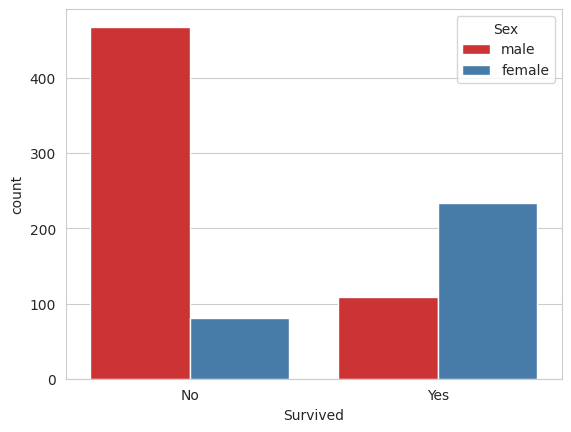

In [65]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue = 'Sex', data=df,palette='Set1')

<Axes: xlabel='Survived', ylabel='count'>

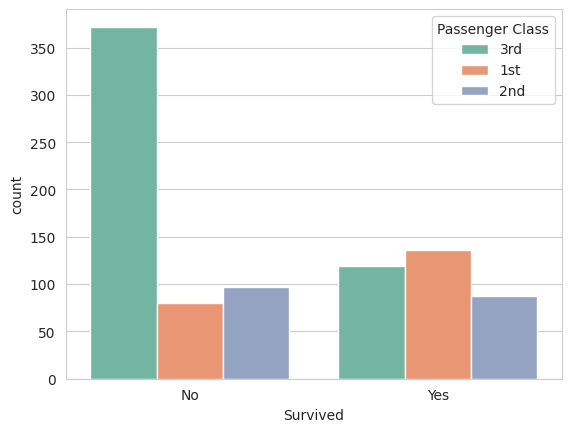

In [66]:

sns.countplot(x='Survived',hue = 'Passenger Class', data=df,palette='Set2')

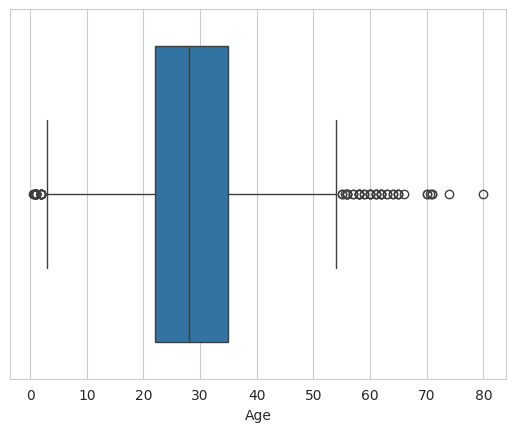

In [67]:

sns.boxplot(x = df['Age'],data = df)
plt.show()

# Final Output

In [69]:
df

,PassengerId,Survived,Passenger Class,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Ticket,Cabin,Embarked,Family_size,Family_type,Fare_per_Person,Log_Fare,Titles,Person_Type,Ticket_Group_Size
0,1,No,3rd,male,22.0,1,0,A/5 21171,U,Southampton,2,Small Family,3.62500,2.110213,Mr,male,1
1,2,Yes,1st,female,38.0,1,0,PC 17599,C,Cherburg,2,Small Family,35.64165,4.280593,Mrs,female,1
2,3,Yes,3rd,female,26.0,0,0,STON/O2. 3101282,U,Southampton,1,Alone,7.92500,2.188856,Miss,female,1
3,4,Yes,1st,female,35.0,1,0,113803,C,Southampton,2,Small Family,26.55000,3.990834,Mrs,female,2
4,5,No,3rd,male,35.0,0,0,373450,U,Southampton,1,Alone,8.05000,2.202765,Mr,male,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,No,2nd,male,27.0,0,0,211536,U,Southampton,1,Alone,13.00000,2.639057,Rare,male,1
887,888,Yes,1st,female,19.0,0,0,112053,B,Southampton,1,Alone,30.00000,3.433987,Miss,female,1
888,889,No,3rd,female,28.0,1,2,W./C. 6607,U,Southampton,4,Small Family,5.86250,3.196630,Miss,female,2
889,890,Yes,1st,male,26.0,0,0,111369,C,Cherburg,1,Alone,30.00000,3.433987,Mr,male,1
